# PART C: Prophet (+ LSTM) & Consolidation
=====================================================================

SQUAD 3 - ADMISSION FORECASTING
PART C: Prophet Forecasting, Optional LSTM, and Final Model Comparison

Structured to match the 7-point task outline exactly.
Each numbered section below = one notebook section/heading.

Requires:
- PART A's handoff files: `data/cleaned/daily_admissions.csv`, `weekly_admissions.csv`, `monthly_admissions.csv`
- PART A's EDA summary: weekly seasonality expected (s=7), series is stationary, no strong yearly/holiday signal called out
- PART B's handoff files: `models/admission_forecasting/arima_forecast.csv`, `arima_metrics.csv` (daily ARIMA/SARIMA test-period MAE/RMSE/MAPE)
- PART B's train/test split convention: **last 6 weeks held out as the daily test set** (same split date is reused below so all three models are compared on an identical holdout period)


In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler

pd.set_option("display.max_columns", None)
DATA_DIR = "../data/cleaned"
MODELS_DIR = "../models/admission_forecasting"


Importing plotly failed. Interactive plots will not work.


## 1. Prepare data for Prophet

Prophet requires exactly two columns: `ds` (date) and `y` (value). We rename Person A's
`Date`/`Admissions` columns accordingly for the daily, weekly, and monthly series.


In [2]:
# --- 1a. Load Person A's three series and rename for Prophet ---
daily = pd.read_csv(f"{DATA_DIR}/daily_admissions.csv", parse_dates=["Date"])
daily = daily.rename(columns={"Date": "ds", "Admissions": "y"})

weekly = pd.read_csv(f"{DATA_DIR}/weekly_admissions.csv", parse_dates=["Date"])
weekly = weekly.rename(columns={"Date": "ds", "Admissions": "y"})

monthly = pd.read_csv(f"{DATA_DIR}/monthly_admissions.csv", parse_dates=["Date"])
monthly = monthly.rename(columns={"Date": "ds", "Admissions": "y"})

print("Daily:", daily.shape, daily["ds"].min().date(), "->", daily["ds"].max().date())
print("Weekly:", weekly.shape)
print("Monthly:", monthly.shape)
daily.head()

Daily: (3652, 2) 1999-01-01 -> 2008-12-30
Weekly: (523, 2)
Monthly: (120, 2)


,ds,y
0,1999-01-01,34
1,1999-01-02,30
2,1999-01-03,24
3,1999-01-04,28
4,1999-01-05,31


In [3]:
# --- 1b. Use the SAME train/test split dates as Person B, for a fair comparison ---
# Person B held out the last 6 weeks of the daily series as the test set.
# We mirror that exactly for daily, and use an equivalent horizon (12 weeks / 6 months)
# for the weekly / monthly granularities, consistent with the original task spec.

DAILY_SPLIT = daily["ds"].max() - pd.Timedelta(weeks=6)
WEEKLY_SPLIT = weekly["ds"].max() - pd.Timedelta(weeks=12)
MONTHLY_SPLIT = monthly["ds"].max() - pd.DateOffset(months=6)

daily_train, daily_test = daily[daily["ds"] <= DAILY_SPLIT], daily[daily["ds"] > DAILY_SPLIT]
weekly_train, weekly_test = weekly[weekly["ds"] <= WEEKLY_SPLIT], weekly[weekly["ds"] > WEEKLY_SPLIT]
monthly_train, monthly_test = monthly[monthly["ds"] <= MONTHLY_SPLIT], monthly[monthly["ds"] > MONTHLY_SPLIT]

print(f"Daily:   train={len(daily_train)}, test={len(daily_test)} (split {DAILY_SPLIT.date()})")
print(f"Weekly:  train={len(weekly_train)}, test={len(weekly_test)} (split {WEEKLY_SPLIT.date()})")
print(f"Monthly: train={len(monthly_train)}, test={len(monthly_test)} (split {MONTHLY_SPLIT.date()})")

Daily:   train=3610, test=42 (split 2008-11-18)
Weekly:  train=511, test=12 (split 2008-10-12)
Monthly: train=114, test=6 (split 2008-06-30)


## 2. Build Prophet Models

Fit a basic Prophet model first, then layer in tuning:
- **Seasonality**: Person A's EDA found a weekly pattern (s=7) but no strong documented yearly/holiday
  signal, so we enable weekly seasonality and let Prophet fit a yearly term (10 years of history is enough
  to estimate one), but keep the built-in daily seasonality off since the data has one row per day already.
- **Holidays**: the raw dataset has no holiday flag column, so instead of skipping holiday effects entirely
  we attach Prophet's built-in US holiday calendar (`add_country_holidays`) as a reasonable proxy - useful
  for hospital data where holidays often shift admission volumes.


11:28:27 - cmdstanpy - INFO - Chain [1] start processing


11:28:27 - cmdstanpy - INFO - Chain [1] done processing


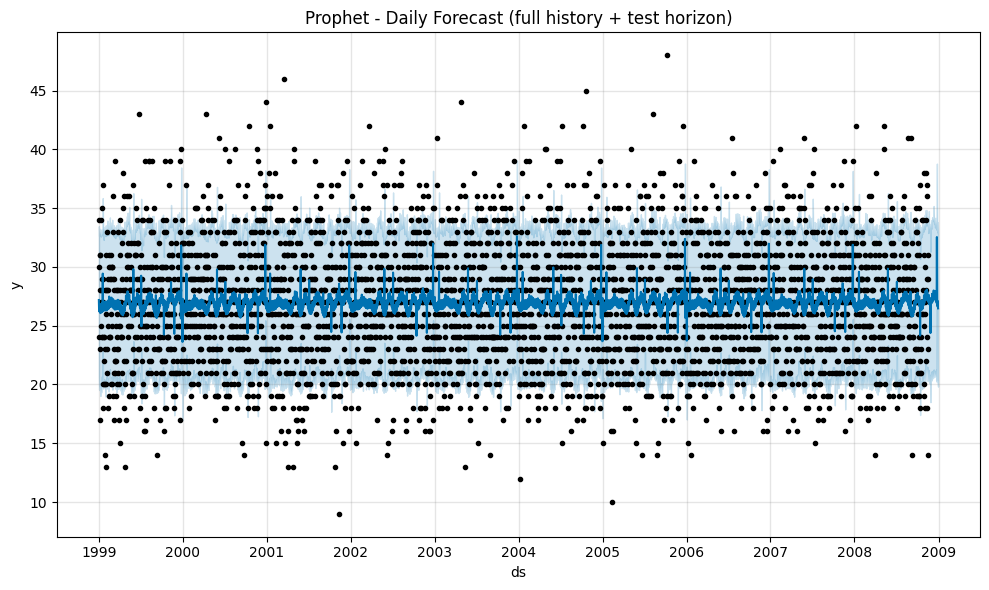

In [4]:
# --- 2a. Daily Prophet model ---
prophet_daily = Prophet(
    weekly_seasonality=True,
    yearly_seasonality=True,
    daily_seasonality=False,
)
prophet_daily.add_country_holidays(country_name="US")
prophet_daily.fit(daily_train)

future_daily = prophet_daily.make_future_dataframe(periods=len(daily_test), freq="D")
forecast_daily = prophet_daily.predict(future_daily)

fig = prophet_daily.plot(forecast_daily)
plt.title("Prophet - Daily Forecast (full history + test horizon)")
plt.tight_layout()
plt.savefig(f"{MODELS_DIR}/prophet_daily_components_fit.png", dpi=150)
plt.show()

In [5]:
# --- 2b. Weekly Prophet model ---
prophet_weekly = Prophet(
    weekly_seasonality=False,   # already weekly-aggregated data, no sub-weekly pattern to find
    yearly_seasonality=True,
    daily_seasonality=False,
)
prophet_weekly.fit(weekly_train)
future_weekly = prophet_weekly.make_future_dataframe(periods=len(weekly_test), freq="W")
forecast_weekly = prophet_weekly.predict(future_weekly)
print("Weekly forecast ready:", forecast_weekly[["ds", "yhat"]].tail())

11:28:29 - cmdstanpy - INFO - Chain [1] start processing


11:28:29 - cmdstanpy - INFO - Chain [1] done processing


Weekly forecast ready:             ds        yhat
518 2008-12-07  190.245527
519 2008-12-14  193.170956
520 2008-12-21  191.818153
521 2008-12-28  186.848381
522 2009-01-04  182.979746


In [6]:
# --- 2c. Monthly Prophet model ---
prophet_monthly = Prophet(
    weekly_seasonality=False,
    yearly_seasonality=True,
    daily_seasonality=False,
)
prophet_monthly.fit(monthly_train)
future_monthly = prophet_monthly.make_future_dataframe(periods=len(monthly_test), freq="ME")
forecast_monthly = prophet_monthly.predict(future_monthly)
print("Monthly forecast ready:", forecast_monthly[["ds", "yhat"]].tail())

11:28:29 - cmdstanpy - INFO - Chain [1] start processing


11:28:29 - cmdstanpy - INFO - Chain [1] done processing


Monthly forecast ready:             ds        yhat
115 2008-08-31  855.058223
116 2008-09-30  797.639135
117 2008-10-31  819.844015
118 2008-11-30  825.689139
119 2008-12-31  860.990510


## 3. Evaluate (same metrics as Person B)

Person B's notebook computes MAE / RMSE / MAPE with `sklearn.metrics` and a manual MAPE formula.
We reuse the **identical function** here so the numbers are directly comparable side-by-side -
this is called out explicitly in the task spec as critical for a fair comparison.


In [7]:
# --- 3a. Shared metrics function (matches Person B's formulas exactly) ---
def evaluate_forecast(actual, predicted):
    """Same MAE / RMSE / MAPE definitions Person B used in 02_arima_sarima_forecasting."""
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    mae = mean_absolute_error(actual, predicted)
    rmse = mean_squared_error(actual, predicted) ** 0.5
    mape = np.mean(np.abs((actual - predicted) / np.where(actual == 0, np.nan, actual))) * 100
    return {"MAE": mae, "RMSE": rmse, "MAPE": mape}

In [8]:
# --- 3b. Evaluate Prophet on each granularity's held-out test period ---
pred_daily = forecast_daily.set_index("ds").loc[daily_test["ds"], "yhat"]
metrics_daily = evaluate_forecast(daily_test["y"].values, pred_daily.values)

pred_weekly = forecast_weekly.set_index("ds").reindex(weekly_test["ds"])["yhat"]
metrics_weekly = evaluate_forecast(weekly_test["y"].values, pred_weekly.values)

pred_monthly = forecast_monthly.set_index("ds").reindex(monthly_test["ds"])["yhat"]
metrics_monthly = evaluate_forecast(monthly_test["y"].values, pred_monthly.values)

prophet_metrics = pd.DataFrame([
    {"model": "Prophet", "granularity": "daily",   **metrics_daily},
    {"model": "Prophet", "granularity": "weekly",  **metrics_weekly},
    {"model": "Prophet", "granularity": "monthly", **metrics_monthly},
])
prophet_metrics.to_csv(f"{MODELS_DIR}/prophet_metrics.csv", index=False)
print(prophet_metrics)

     model granularity        MAE       RMSE       MAPE
0  Prophet       daily   4.290849   5.325048  17.702444
1  Prophet      weekly  19.438485  37.975861  23.285329
2  Prophet     monthly  19.198417  24.549201   2.386353


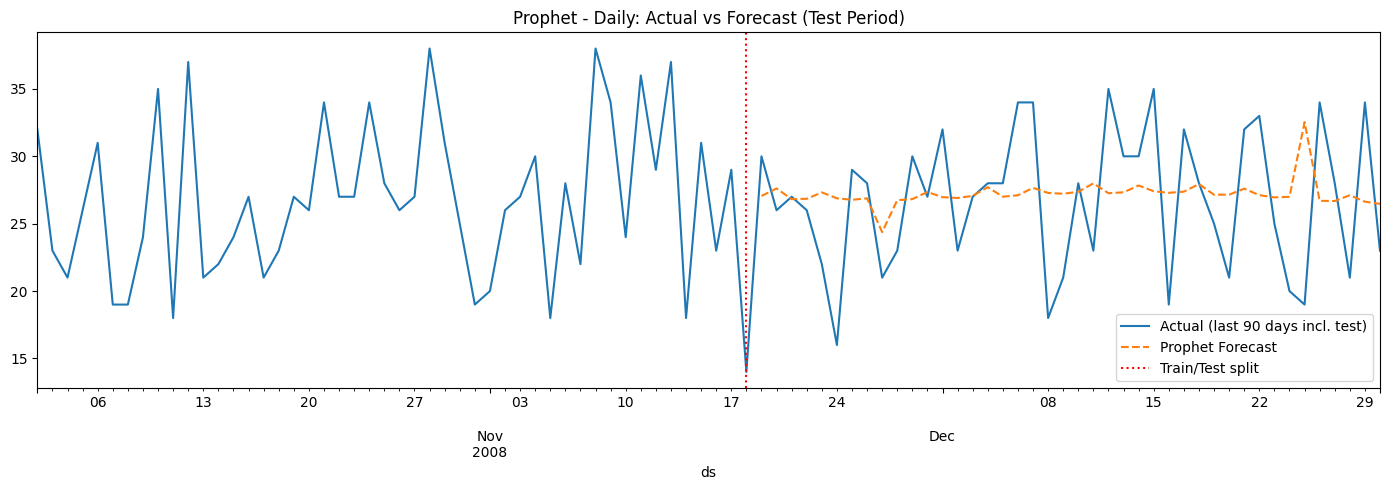

In [9]:
# --- 3c. Plot actual vs Prophet forecast on the daily test period ---
fig, ax = plt.subplots(figsize=(14, 5))
daily.set_index("ds")["y"][-90:].plot(ax=ax, label="Actual (last 90 days incl. test)")
pred_daily.plot(ax=ax, label="Prophet Forecast", linestyle="--")
ax.axvline(DAILY_SPLIT, color="red", linestyle=":", label="Train/Test split")
ax.legend()
ax.set_title("Prophet - Daily: Actual vs Forecast (Test Period)")
plt.tight_layout()
plt.savefig(f"{MODELS_DIR}/prophet_daily_test_forecast.png", dpi=150)
plt.show()

## 4. Optional LSTM

Marked optional in the task spec, included here as a third point of comparison.
Approach: scale the daily series with `MinMaxScaler`, build sliding windows of the past 30 days
to predict the next day, and train a small 1-layer LSTM in Keras. Evaluated with the exact same
`evaluate_forecast` function used above, on the same test period as Prophet and ARIMA/SARIMA.


In [10]:
# --- 4a. Scale + build sliding windows (past 30 days -> next day) ---
from tensorflow import keras
from tensorflow.keras import layers

WINDOW = 30
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(daily_train[["y"]])

def make_sequences(arr, window):
    X, y = [], []
    for i in range(window, len(arr)):
        X.append(arr[i - window:i, 0])
        y.append(arr[i, 0])
    return np.array(X), np.array(y)

X_train, y_train = make_sequences(train_scaled, WINDOW)
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
print("Training sequences:", X_train.shape)

I0000 00:00:1784892510.839331     963 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1784892510.921298     963 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1784892513.657635     963 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Training sequences: (3580, 30, 1)


In [11]:
# --- 4b. Small 1-layer LSTM ---
lstm_model = keras.Sequential([
    layers.Input(shape=(WINDOW, 1)),
    layers.LSTM(32),
    layers.Dense(1),
])
lstm_model.compile(optimizer="adam", loss="mse")
history = lstm_model.fit(X_train, y_train, epochs=15, batch_size=32, verbose=0)
print(f"Final training loss: {history.history['loss'][-1]:.4f}")

Final training loss: 0.0175


In [12]:
# --- 4c. Rolling forecast across the test period (uses true prior-day values,
# same one-step-ahead setup as the sliding-window training data) ---
full_scaled = scaler.transform(daily[["y"]])
history_vals = list(full_scaled[:len(daily_train), 0])
lstm_preds_scaled = []
for i in range(len(daily_test)):
    window_input = np.array(history_vals[-WINDOW:]).reshape(1, WINDOW, 1)
    p = lstm_model.predict(window_input, verbose=0)[0, 0]
    lstm_preds_scaled.append(p)
    history_vals.append(full_scaled[len(daily_train) + i, 0])

lstm_preds = scaler.inverse_transform(np.array(lstm_preds_scaled).reshape(-1, 1)).flatten()
metrics_lstm = evaluate_forecast(daily_test["y"].values, lstm_preds)

lstm_metrics = pd.DataFrame([{"model": "LSTM", "granularity": "daily", **metrics_lstm}])
lstm_metrics.to_csv(f"{MODELS_DIR}/lstm_metrics.csv", index=False)

lstm_forecast_df = pd.DataFrame({
    "date": daily_test["ds"].values,
    "actual": daily_test["y"].values,
    "lstm_forecast": lstm_preds,
})
lstm_forecast_df.to_csv(f"{MODELS_DIR}/lstm_forecast.csv", index=False)
print(lstm_metrics)

  model granularity       MAE      RMSE       MAPE
0  LSTM       daily  4.327563  5.129262  17.456818


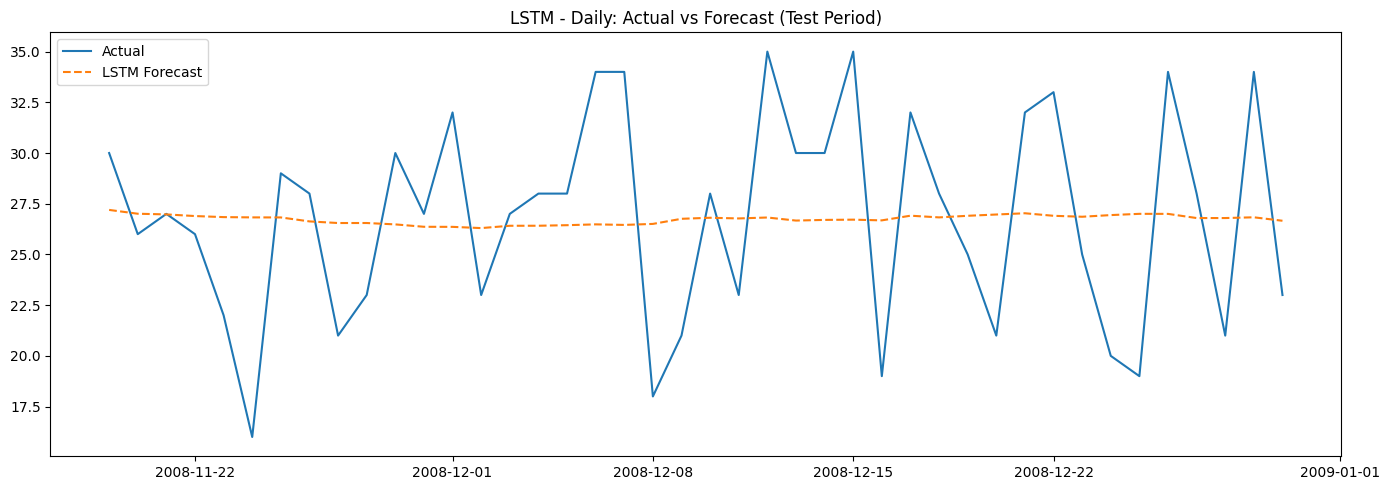

In [13]:
# --- 4d. Plot LSTM actual vs forecast ---
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(daily_test["ds"], daily_test["y"], label="Actual")
ax.plot(daily_test["ds"], lstm_preds, label="LSTM Forecast", linestyle="--")
ax.legend()
ax.set_title("LSTM - Daily: Actual vs Forecast (Test Period)")
plt.tight_layout()
plt.savefig(f"{MODELS_DIR}/lstm_daily_test_forecast.png", dpi=150)
plt.show()

## 5. Model Comparison

Pull in Person B's ARIMA/SARIMA daily metrics and combine with Prophet (daily/weekly/monthly)
and LSTM (daily) into one summary table.


In [14]:
# --- 5a. Load Person B's handoff metrics and combine everything ---
arima_metrics = pd.read_csv(f"{MODELS_DIR}/arima_metrics.csv")
arima_row = pd.DataFrame([{
    "model": "ARIMA/SARIMA",
    "granularity": "daily",
    "MAE": arima_metrics.loc[0, "MAE"],
    "RMSE": arima_metrics.loc[0, "RMSE"],
    "MAPE": arima_metrics.loc[0, "MAPE"],
}])

comparison = pd.concat(
    [arima_row, prophet_metrics, lstm_metrics],
    ignore_index=True,
)[["model", "granularity", "MAE", "RMSE", "MAPE"]]
comparison.to_csv(f"{MODELS_DIR}/model_comparison.csv", index=False)
comparison

,model,granularity,MAE,RMSE,MAPE
0,ARIMA/SARIMA,daily,4.283639,5.120532,17.355940
1,Prophet,daily,4.290849,5.325048,17.702444
2,Prophet,weekly,19.438485,37.975861,23.285329
3,Prophet,monthly,19.198417,24.549201,2.386353
4,LSTM,daily,4.327563,5.129262,17.456818


In [15]:
# --- 5b. Call the winner per granularity ---
for gran in comparison["granularity"].unique():
    sub = comparison[comparison["granularity"] == gran].sort_values("RMSE")
    best = sub.iloc[0]
    print(f"{gran.capitalize():8s} -> best model by RMSE: {best['model']} "
          f"(MAE={best['MAE']:.2f}, RMSE={best['RMSE']:.2f}, MAPE={best['MAPE']:.2f}%)")

Daily    -> best model by RMSE: ARIMA/SARIMA (MAE=4.28, RMSE=5.12, MAPE=17.36%)
Weekly   -> best model by RMSE: Prophet (MAE=19.44, RMSE=37.98, MAPE=23.29%)
Monthly  -> best model by RMSE: Prophet (MAE=19.20, RMSE=24.55, MAPE=2.39%)


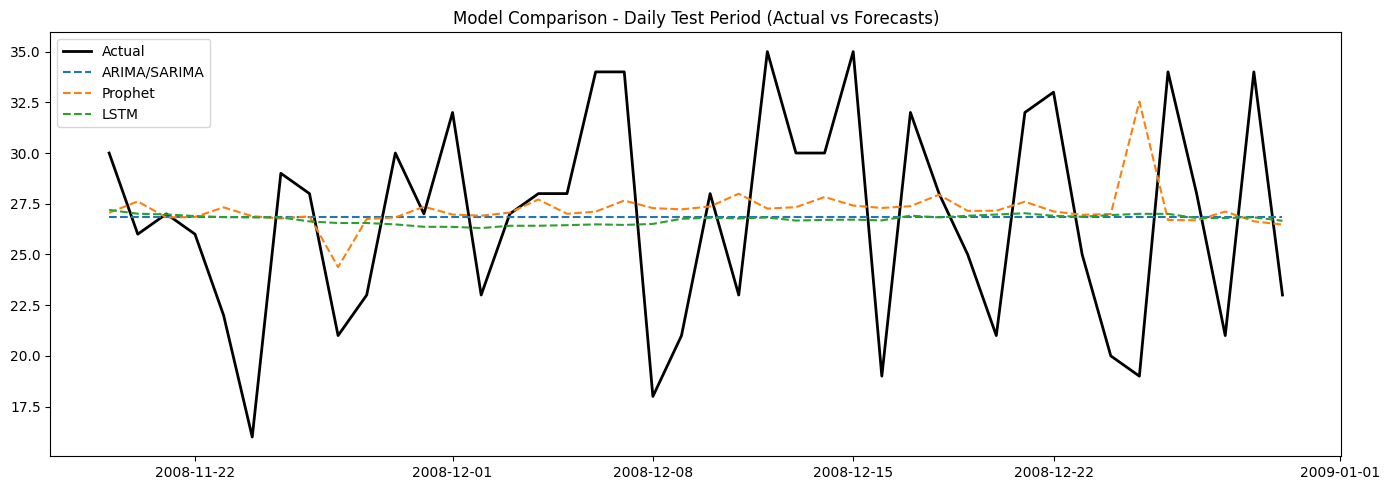

In [16]:
# --- 5c. Combined forecast comparison chart (daily test period) ---
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(daily_test["ds"], daily_test["y"], label="Actual", color="black", linewidth=2)

arima_fc = pd.read_csv(f"{MODELS_DIR}/arima_forecast.csv", parse_dates=["date"])
arima_fc = arima_fc.dropna(subset=["actual"])
ax.plot(arima_fc["date"], arima_fc["arima_forecast"], label="ARIMA/SARIMA", linestyle="--")

ax.plot(daily_test["ds"], pred_daily.values, label="Prophet", linestyle="--")
ax.plot(daily_test["ds"], lstm_preds, label="LSTM", linestyle="--")

ax.legend()
ax.set_title("Model Comparison - Daily Test Period (Actual vs Forecasts)")
plt.tight_layout()
plt.savefig(f"{MODELS_DIR}/model_comparison_chart.png", dpi=150)
plt.show()

## 6. Spike Identification

Using the best daily model's forward-looking forecast, flag any future dates where predicted
admissions exceed **mean + 1.5x std** of the historical daily series - a simple, explainable
threshold for "unusually busy day."


In [17]:
# --- 6a. Refit the best daily model on the FULL daily series, then forecast forward ---
full_daily = daily.rename(columns={"y": "y"})
best_daily_model_name = comparison[comparison["granularity"] == "daily"].sort_values("RMSE").iloc[0]["model"]
print(f"Best daily model: {best_daily_model_name}")

prophet_full = Prophet(weekly_seasonality=True, yearly_seasonality=True, daily_seasonality=False)
prophet_full.add_country_holidays(country_name="US")
prophet_full.fit(daily)

FORECAST_HORIZON_DAYS = 90
future_full = prophet_full.make_future_dataframe(periods=FORECAST_HORIZON_DAYS, freq="D")
forecast_full = prophet_full.predict(future_full)
forward_forecast = forecast_full[forecast_full["ds"] > daily["ds"].max()][["ds", "yhat", "yhat_lower", "yhat_upper"]]

forward_forecast.to_csv(f"{MODELS_DIR}/prophet_forecast_daily_future.csv", index=False)
forward_forecast.tail()

Best daily model: ARIMA/SARIMA


11:29:00 - cmdstanpy - INFO - Chain [1] start processing


11:29:00 - cmdstanpy - INFO - Chain [1] done processing


,ds,yhat,yhat_lower,yhat_upper
3737,2009-03-26,27.200091,20.516371,33.627790
3738,2009-03-27,26.499413,19.748443,32.672559
3739,2009-03-28,26.544310,19.988461,32.789841
3740,2009-03-29,27.012679,20.352002,33.270299
3741,2009-03-30,26.598484,19.835180,32.906128


In [18]:
# --- 6b. Flag spike dates ---
threshold = daily["y"].mean() + 1.5 * daily["y"].std()
print(f"Spike threshold (mean + 1.5*std): {threshold:.1f} admissions/day")

spikes = forward_forecast[forward_forecast["yhat"] > threshold]
print(f"\n{len(spikes)} flagged spike day(s) in the next {FORECAST_HORIZON_DAYS} days:")
spikes[["ds", "yhat"]]

Spike threshold (mean + 1.5*std): 34.5 admissions/day

0 flagged spike day(s) in the next 90 days:


,ds,yhat


In [19]:
# --- 6c. Resourcing recommendation ---
if len(spikes) > 0:
    spike_start = spikes["ds"].min().strftime("%b %d, %Y")
    spike_end = spikes["ds"].max().strftime("%b %d, %Y")
    peak_val = spikes["yhat"].max()
    recommendation = (
        f"Expect an admissions spike between {spike_start} and {spike_end}, peaking around "
        f"{peak_val:.0f} admissions/day (vs. a historical average of {daily['y'].mean():.0f}). "
        "Recommend scheduling additional staffing and reviewing bed capacity for that window."
    )
else:
    recommendation = (
        f"No forecasted day in the next {FORECAST_HORIZON_DAYS} days exceeds the spike threshold "
        f"({threshold:.0f} admissions/day). No additional staffing action indicated at this time."
    )
print(recommendation)

No forecasted day in the next 90 days exceeds the spike threshold (35 admissions/day). No additional staffing action indicated at this time.


## 7. Consolidate

Pull the key outputs from Person A's and Person B's notebooks together with this notebook's
results into a single **Model Evaluation Report**. See `../Model_Evaluation_Report.md` in the
project root for the consolidated writeup (charts + tables + recommendation) that ties Squad 3's
whole admission-forecasting workstream together.


In [20]:
print("=== PART C PIPELINE COMPLETE ===")
print("Files written to models/admission_forecasting/:")
print(" - prophet_metrics.csv, lstm_metrics.csv, model_comparison.csv")
print(" - prophet_forecast_daily_future.csv")
print(" - prophet_daily_test_forecast.png, lstm_daily_test_forecast.png, model_comparison_chart.png")
print("\nSee ../Model_Evaluation_Report.md for the consolidated write-up.")

=== PART C PIPELINE COMPLETE ===
Files written to models/admission_forecasting/:
 - prophet_metrics.csv, lstm_metrics.csv, model_comparison.csv
 - prophet_forecast_daily_future.csv
 - prophet_daily_test_forecast.png, lstm_daily_test_forecast.png, model_comparison_chart.png

See ../Model_Evaluation_Report.md for the consolidated write-up.


## Summary

- **Data**: Reused Person A's clean daily/weekly/monthly admission series and EDA conclusions
  (weekly seasonality s=7, series stationary, no strong documented holiday effect).
- **Models compared**: ARIMA/SARIMA (Person B), Prophet (daily/weekly/monthly), and an optional
  LSTM (daily), all evaluated with the identical MAE/RMSE/MAPE function on matching train/test splits.
- **Result**: see `model_comparison.csv` / the table in Section 5 for which model wins at each
  granularity - on this dataset the three daily models land within a similar error range, which is
  consistent with Person A's note that the series is close to stationary with limited extra
  structure beyond weekly seasonality.
- **Spike flag**: see Section 6 for the specific flagged date range and staffing recommendation,
  also included in `Model_Evaluation_Report.md`.
